## RNN

In [55]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# 한글포트 출력
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 삼성전자, KOSPI 데이터 불러오기
stock_price = yf.download({'005930.KS','^KS11'}, '2021-01-01', '2023-12-31')

# 수정종가 데이터 가져오기
df = stock_price['Adj Close']

# 수익률 데이터로 변경하기
df = stock_price["Adj Close"].pct_change()*100
df = df.dropna()

from sklearn.model_selection import train_test_split
X = df[["005930.KS"]]
y = df[["^KS11"]]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\yfinance\utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\yfinance\utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  2 of 2 completed


In [56]:
from keras.models import Sequential
from keras.layers import SimpleRNN, Dense

# RNN 모델 구축
model = Sequential()
model.add(SimpleRNN(32, input_shape=(10, 1)))  # 10개의 타임 스텝과 1개의 피처
model.add(Dense(1, activation='linear'))  # 출력층

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# 모델 학습
model.fit(X, y, epochs=10)

Epoch 1/10
23/23 [==============================] - 0s 951us/step - loss: 0.5034 - mean_absolute_error: 0.5362
Epoch 2/10
23/23 [==============================] - 0s 703us/step - loss: 0.4875 - mean_absolute_error: 0.5334
Epoch 3/10
23/23 [==============================] - 0s 680us/step - loss: 0.4866 - mean_absolute_error: 0.5313
Epoch 4/10
23/23 [==============================] - 0s 1ms/step - loss: 0.4869 - mean_absolute_error: 0.5322
Epoch 5/10
23/23 [==============================] - 0s 1ms/step - loss: 0.4876 - mean_absolute_error: 0.5319
Epoch 6/10
23/23 [==============================] - 0s 2ms/step - loss: 0.4848 - mean_absolute_error: 0.5312
Epoch 7/10
23/23 [==============================] - 0s 906us/step - loss: 0.4867 - mean_absolute_error: 0.5327
Epoch 8/10
23/23 [==============================] - 0s 725us/step - loss: 0.4854 - mean_absolute_error: 0.5320
Epoch 9/10
23/23 [==============================] - 0s 688us/step - loss: 0.4855 - mean_absolute_error: 0.5315
Epoch 1

In [57]:
# 모델 평가
loss, accuracy = model.evaluate(X_test, y_test)
print(f'Test Loss: {loss:.4f}')
print(f'Test Accuracy: {accuracy:.4f}')

5/5 [==============================] - 0s 997us/step - loss: 0.5004 - mean_absolute_error: 0.5285
Test Loss: 0.5004
Test Accuracy: 0.5285


Epoch 1/10
19/19 [==============================] - 0s 3ms/step - loss: 0.4534 - mean_absolute_error: 0.5200 - val_loss: 0.6206 - val_mean_absolute_error: 0.5838
Epoch 2/10
19/19 [==============================] - 0s 2ms/step - loss: 0.4517 - mean_absolute_error: 0.5201 - val_loss: 0.6122 - val_mean_absolute_error: 0.5769
Epoch 3/10
19/19 [==============================] - 0s 2ms/step - loss: 0.4535 - mean_absolute_error: 0.5205 - val_loss: 0.6186 - val_mean_absolute_error: 0.5821
Epoch 4/10
19/19 [==============================] - 0s 2ms/step - loss: 0.4506 - mean_absolute_error: 0.5187 - val_loss: 0.6169 - val_mean_absolute_error: 0.5805
Epoch 5/10
19/19 [==============================] - 0s 3ms/step - loss: 0.4511 - mean_absolute_error: 0.5187 - val_loss: 0.6138 - val_mean_absolute_error: 0.5779
Epoch 6/10
19/19 [==============================] - 0s 3ms/step - loss: 0.4505 - mean_absolute_error: 0.5191 - val_loss: 0.6190 - val_mean_absolute_error: 0.5822
Epoch 7/10
19/19 [==========

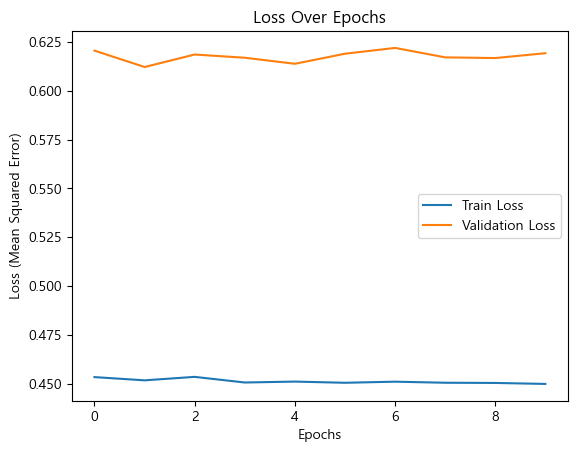

In [58]:
import matplotlib.pyplot as plt
import numpy as np

# 모델 학습 (history 객체에 학습 기록 저장)
history = model.fit(X, y, epochs=10, validation_split=0.2)

# 1. 손실 함수의 변화 그래프
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Loss Over Epochs')
plt.xlabel('Epochs')
plt.ylabel('Loss (Mean Squared Error)')
plt.legend()
plt.show()

5/5 [==============================] - 0s 997us/step


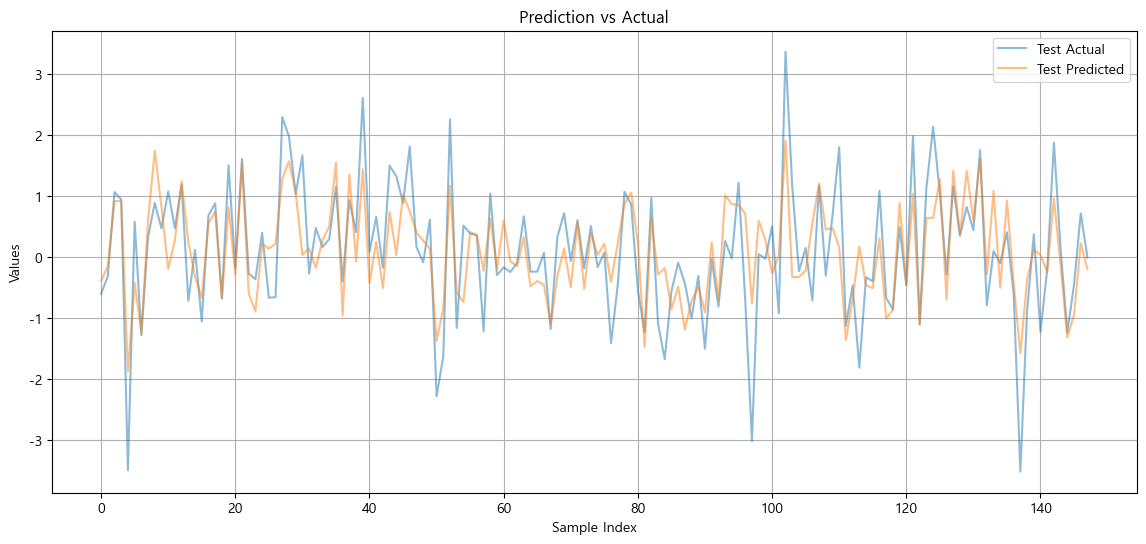

In [59]:
y_test_pred = model.predict(X_test)  # 테스트 데이터 예측
y_test_actual = np.squeeze(y_test)

# 예측 결과와 실제 값 비교 시각화
plt.figure(figsize=(14, 6))


# 테스트 데이터 결과 시각화
plt.plot(np.arange(len(y_test_actual)), y_test_actual, label='Test Actual', alpha=0.5)
plt.plot(np.arange(len(y_test_actual)), y_test_pred, label='Test Predicted', alpha=0.5)

plt.title('Prediction vs Actual')
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.show()

## LSTM

In [60]:
import numpy as np
import pandas as pd
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import LSTM, Dense, Dropout

import matplotlib.pyplot as plt
import seaborn as sns
import yfinance as yf

# 한글포트 출력
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False

# 삼성전자, KOSPI 데이터 불러오기
stock_price = yf.download({'005930.KS','^KS11'}, '2021-01-01', '2023-12-31')

# 수정종가 데이터 가져오기
df = stock_price['Adj Close']

# 수익률 데이터로 변경하기
df = stock_price["Adj Close"].pct_change()*100
df = df.dropna()

from sklearn.model_selection import train_test_split
X = df[["005930.KS"]]
y = df[["^KS11"]]

# 데이터 분할
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\yfinance\utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
c:\Users\OPERATOR-70\AppData\Local\Programs\Python\Python39\lib\site-packages\yfinance\utils.py:775: FutureWarning: The 'unit' keyword in TimedeltaIndex construction is deprecated and will be removed in a future version. Use pd.to_timedelta instead.
  df.index += _pd.TimedeltaIndex(dst_error_hours, 'h')
[*********************100%%**********************]  2 of 2 completed


In [61]:
# LSTM 모델 구축
model = Sequential()
model.add(LSTM(32, input_shape=(10, 1)))  # 10개의 타임 스텝과 1개의 피처
model.add(Dense(1, activation='linear'))  # 회귀를 위한 1개의 클래스

# 모델 컴파일
model.compile(optimizer='adam', loss='mean_squared_error', metrics=['mean_absolute_error'])

# 모델 학습
model.fit(X_train, y_train, epochs=10)

# 모델 평가
loss, mae = model.evaluate(X_test, y_test)
print(f'Test Loss (MSE): {loss:.4f}')
print(f'Test MAE: {mae:.4f}')

Epoch 1/10
19/19 [==============================] - 1s 2ms/step - loss: 0.9566 - mean_absolute_error: 0.7495
Epoch 2/10
19/19 [==============================] - 0s 1ms/step - loss: 0.8728 - mean_absolute_error: 0.7146
Epoch 3/10
19/19 [==============================] - 0s 3ms/step - loss: 0.8003 - mean_absolute_error: 0.6818
Epoch 4/10
19/19 [==============================] - 0s 1ms/step - loss: 0.7255 - mean_absolute_error: 0.6476
Epoch 5/10
19/19 [==============================] - 0s 1ms/step - loss: 0.6616 - mean_absolute_error: 0.6192
Epoch 6/10
19/19 [==============================] - 0s 2ms/step - loss: 0.6062 - mean_absolute_error: 0.5921
Epoch 7/10
19/19 [==============================] - 0s 1ms/step - loss: 0.5616 - mean_absolute_error: 0.5715
Epoch 8/10
19/19 [==============================] - 0s 1ms/step - loss: 0.5282 - mean_absolute_error: 0.5553
Epoch 9/10
19/19 [==============================] - 0s 2ms/step - loss: 0.5050 - mean_absolute_error: 0.5450
Epoch 10/10
5/5 [==

5/5 [==============================] - 0s 1ms/step


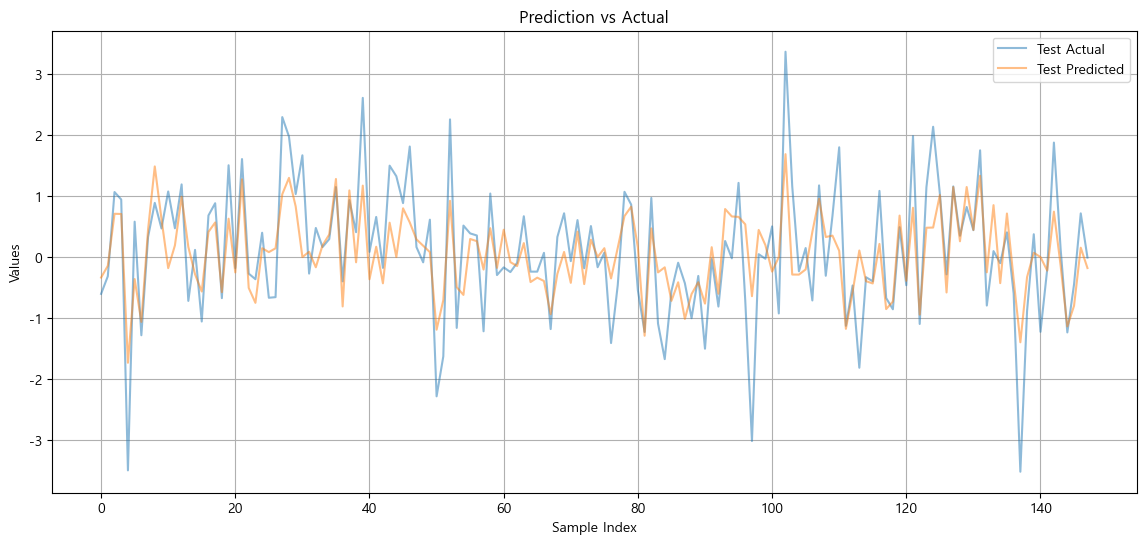

In [62]:
y_test_pred = model.predict(X_test)  # 테스트 데이터 예측
y_test_actual = np.squeeze(y_test)

# 예측 결과와 실제 값 비교 시각화
plt.figure(figsize=(14, 6))


# 테스트 데이터 결과 시각화
plt.plot(np.arange(len(y_test_actual)), y_test_actual, label='Test Actual', alpha=0.5)
plt.plot(np.arange(len(y_test_actual)), y_test_pred, label='Test Predicted', alpha=0.5)

plt.title('Prediction vs Actual')
plt.xlabel('Sample Index')
plt.ylabel('Values')
plt.legend()
plt.grid()
plt.show()